In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from scipy.stats import ttest_ind, f_oneway
import scipy.stats as stats
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Load datasets And Cleaning Phase


In [ ]:

# Load datasets
sales_df = pd.read_csv('sales_data.csv')
churn_df = pd.read_csv('customer_churn.csv')

print("===== SALES DATA =====")
print(sales_df.head())
print(sales_df.info())

print("\n===== CHURN DATA =====")
print(churn_df.head())
print(churn_df.info())

# Check missing values
print("\nMissing values in Sales Data")
print(sales_df.isnull().sum())

print("\nMissing values in Churn Data")
print(churn_df.isnull().sum())

# Remove duplicates
sales_df.drop_duplicates(inplace=True)
churn_df.drop_duplicates(inplace=True)

# Convert date column
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

print("\nData cleaning completed successfully!")

===== SALES DATA =====
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None


## Descriptive Statistics


In [ ]:
#  Descriptive  Statistics

print("===== SALES DATA DESCRIPTIVE STATISTICS =====")
print(sales_df.describe())

print("\n===== SALES MEDIAN =====")
print(sales_df.median(numeric_only=True))

print("\n===== SALES MODE =====")
print(sales_df.mode())

print("\n===== SALES STANDARD DEVIATION =====")
print(sales_df.std(numeric_only=True))

print("\n============================================")

print("\n===== CHURN DATA DESCRIPTIVE STATISTICS =====")
print(churn_df.describe())

print("\n===== CHURN MEDIAN =====")
print(churn_df.median(numeric_only=True))

print("\n===== CHURN STANDARD DEVIATION =====")
print(churn_df.std(numeric_only=True))

===== SALES DATA DESCRIPTIVE STATISTICS =====
                      Date    Quantity         Price    Total_Sales
count                  100  100.000000    100.000000     100.000000
mean   2024-02-19 12:00:00    4.780000  25808.510000  123650.480000
min    2024-01-01 00:00:00    1.000000   1308.000000    6540.000000
25%    2024-01-25 18:00:00    2.750000  14965.250000   39517.500000
50%    2024-02-19 12:00:00    5.000000  24192.000000   97955.500000
75%    2024-03-15 06:00:00    7.000000  38682.250000  175792.500000
max    2024-04-09 00:00:00    9.000000  49930.000000  373932.000000
std                    NaN    2.588163  13917.630242  100161.085275

===== SALES MEDIAN =====
Quantity           5.0
Price          24192.0
Total_Sales    97955.5
dtype: float64

===== SALES MODE =====
         Date Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01  Tablet       4.0   1308     CUST001  North         6540
1  2024-01-02     NaN       NaN   2603     CUST002    NaN         

## Distribution Analysis

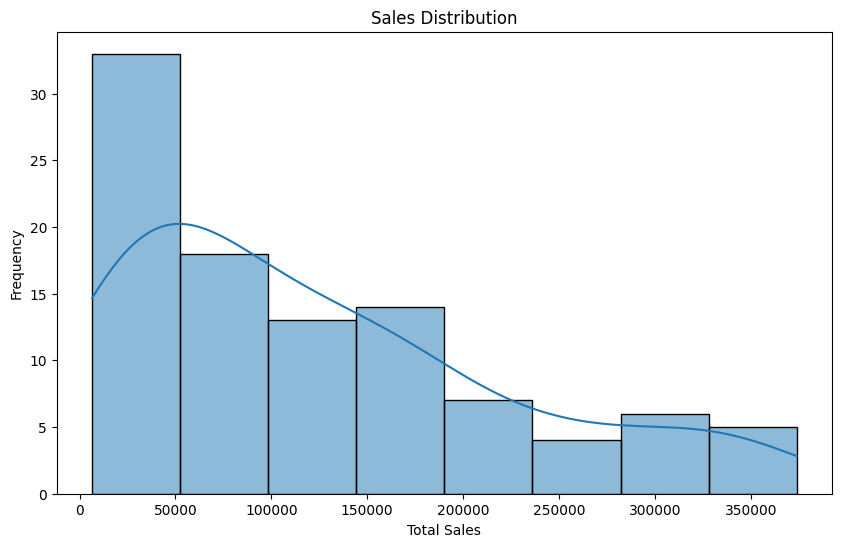

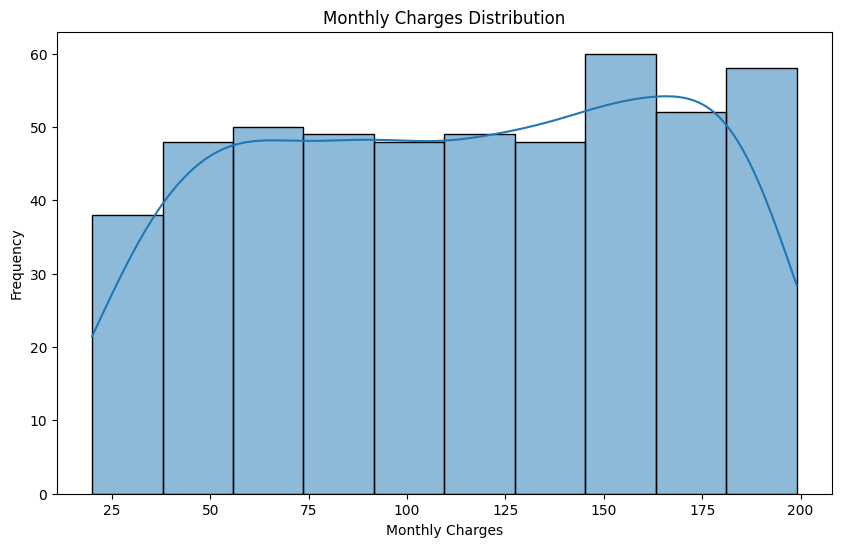

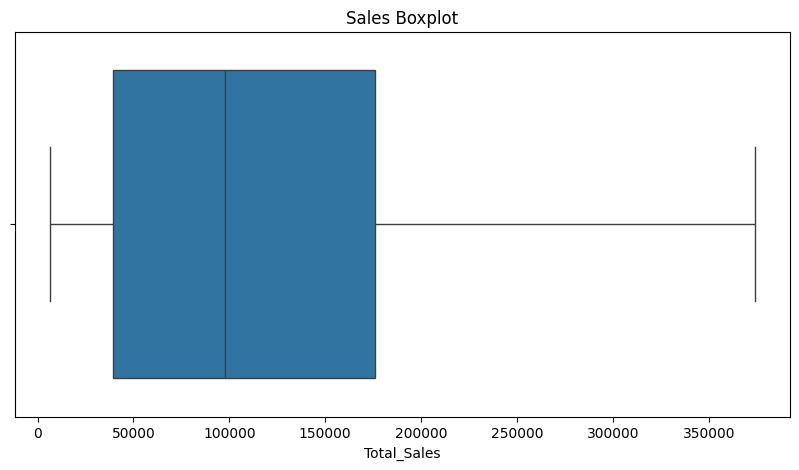

===== SHAPIRO NORMALITY TEST =====
Statistic: 0.8989262036779536
P-value: 1.2590767205714734e-06
Sales data does not follow normal distribution


In [ ]:
# ------------------------------------------------
# Sales Histogram
# ------------------------------------------------

plt.figure(figsize=(10, 6))
sns.histplot(sales_df['Total_Sales'], kde=True)
plt.title('Sales Distribution')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

# ------------------------------------------------
# Monthly Charges Histogram
# ------------------------------------------------

plt.figure(figsize=(10, 6))
sns.histplot(churn_df['MonthlyCharges'], kde=True)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()

# ------------------------------------------------
# Boxplot
# ------------------------------------------------

plt.figure(figsize=(10, 5))
sns.boxplot(x=sales_df['Total_Sales'])
plt.title('Sales Boxplot')
plt.show()

# ------------------------------------------------
# Normality Test
# ------------------------------------------------

stat, p = shapiro(sales_df['Total_Sales'])

print("===== SHAPIRO NORMALITY TEST =====")
print(f"Statistic: {stat}")
print(f"P-value: {p}")

if p > 0.05:
    print("Sales data follows normal distribution")
else:
    print("Sales data does not follow normal distribution")

## Correlatin Analysis

===== SALES DATA CORRELATION ANALYSIS =====


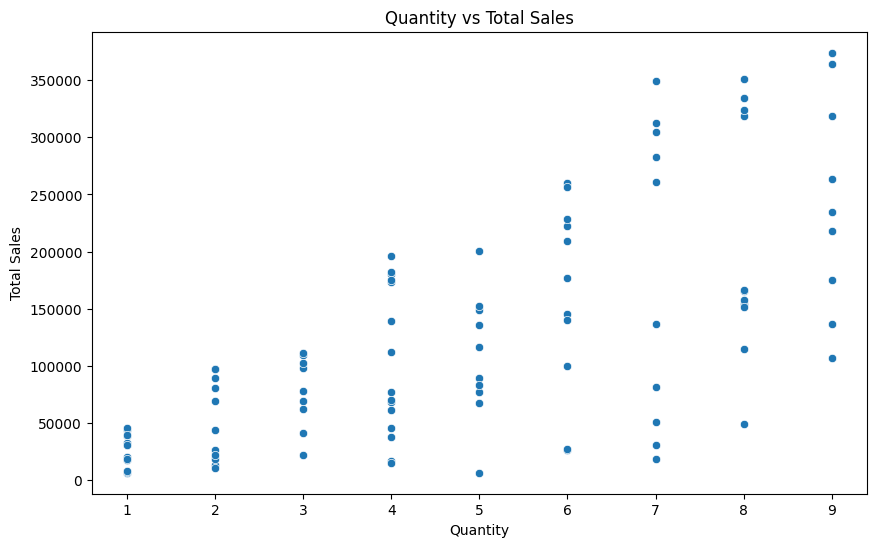


Quantity vs Total Sales Correlation:
Correlation Coefficient: 0.69
Moderate Positive Correlation
Quantity has some positive effect on Total Sales.


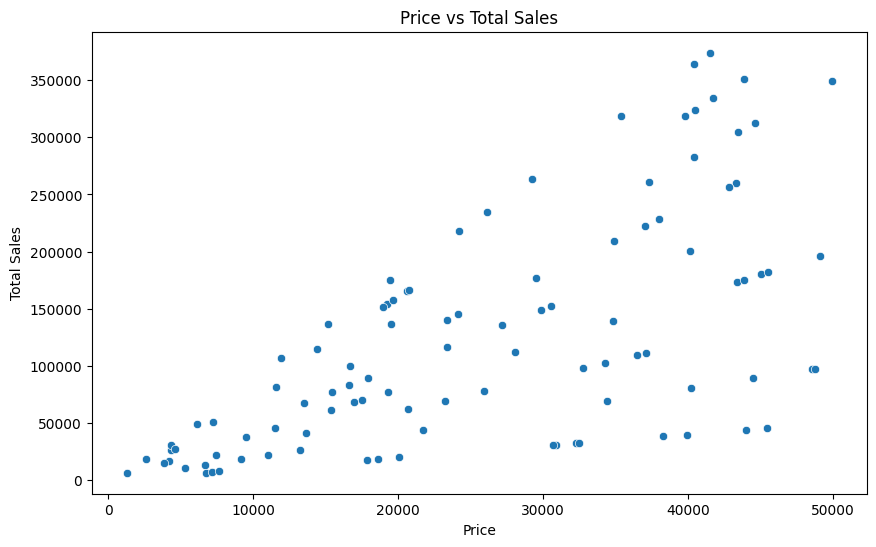


Price vs Total Sales Correlation:
Correlation Coefficient: 0.65
Moderate Positive Correlation
Price moderately affects Total Sales.

===== CHURN DATA CORRELATION ANALYSIS =====


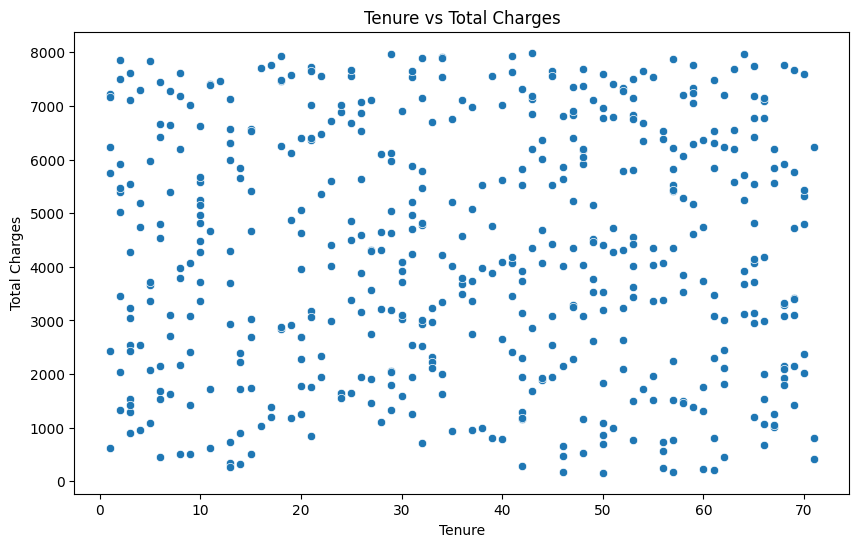


Tenure vs Total Charges Correlation:
Correlation Coefficient: -0.01
Weak Correlation
Tenure has little effect on Total Charges.


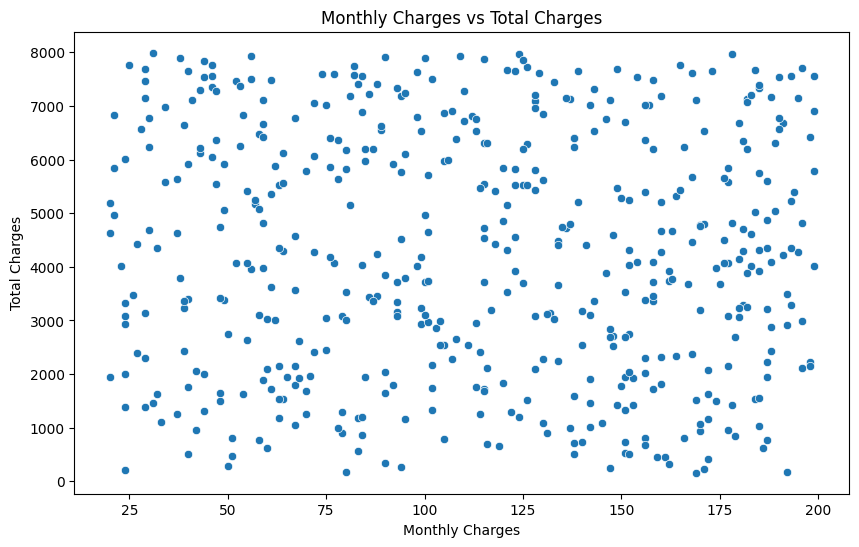


Monthly Charges vs Total Charges Correlation:
Correlation Coefficient: -0.04
Weak Correlation
Monthly charges have little effect on Total Charges.


In [ ]:

print("===== SALES DATA CORRELATION ANALYSIS =====")

# ------------------------------------------------
# Scatter Plot: Quantity vs Total Sales
# ------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Quantity',
    y='Total_Sales',
    data=sales_df
)

plt.title('Quantity vs Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')

plt.show()

# Correlation Value
corr1 = sales_df['Quantity'].corr(sales_df['Total_Sales'])

print("\nQuantity vs Total Sales Correlation:")
print(f"Correlation Coefficient: {corr1:.2f}")

# Interpretation
if corr1 > 0.7:
    print("Strong Positive Correlation")
    print("As Quantity increases, Total Sales also increase significantly.")
elif corr1 > 0.3:
    print("Moderate Positive Correlation")
    print("Quantity has some positive effect on Total Sales.")
else:
    print("Weak Correlation")
    print("Quantity does not strongly affect Total Sales.")

# ------------------------------------------------
# Scatter Plot: Price vs Total Sales
# ------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Price',
    y='Total_Sales',
    data=sales_df
)

plt.title('Price vs Total Sales')
plt.xlabel('Price')
plt.ylabel('Total Sales')

plt.show()

# Correlation Value
corr2 = sales_df['Price'].corr(sales_df['Total_Sales'])

print("\nPrice vs Total Sales Correlation:")
print(f"Correlation Coefficient: {corr2:.2f}")

# Interpretation
if corr2 > 0.7:
    print("Strong Positive Correlation")
    print("Higher product prices contribute strongly to higher sales revenue.")
elif corr2 > 0.3:
    print("Moderate Positive Correlation")
    print("Price moderately affects Total Sales.")
else:
    print("Weak Correlation")
    print("Price has little effect on Total Sales.")

# =========================================================
# CHURN DATA CORRELATION ANALYSIS
# =========================================================

print("\n===== CHURN DATA CORRELATION ANALYSIS =====")

# ------------------------------------------------
# Scatter Plot: Tenure vs Total Charges
# ------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Tenure',
    y='TotalCharges',
    data=churn_df
)

plt.title('Tenure vs Total Charges')
plt.xlabel('Tenure')
plt.ylabel('Total Charges')

plt.show()

# Correlation Value
corr3 = churn_df['Tenure'].corr(churn_df['TotalCharges'])

print("\nTenure vs Total Charges Correlation:")
print(f"Correlation Coefficient: {corr3:.2f}")

# Interpretation
if corr3 > 0.7:
    print("Strong Positive Correlation")
    print("Customers with longer tenure spend significantly more money.")
elif corr3 > 0.3:
    print("Moderate Positive Correlation")
    print("Tenure moderately affects Total Charges.")
else:
    print("Weak Correlation")
    print("Tenure has little effect on Total Charges.")

# ------------------------------------------------
# Scatter Plot: Monthly Charges vs Total Charges
# ------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    data=churn_df
)

plt.title('Monthly Charges vs Total Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')

plt.show()

# Correlation Value
corr4 = churn_df['MonthlyCharges'].corr(churn_df['TotalCharges'])

print("\nMonthly Charges vs Total Charges Correlation:")
print(f"Correlation Coefficient: {corr4:.2f}")

# Interpretation
if corr4 > 0.7:
    print("Strong Positive Correlation")
    print("Higher monthly charges lead to significantly higher total customer spending.")
elif corr4 > 0.3:
    print("Moderate Positive Correlation")
    print("Monthly charges moderately affect Total Charges.")
else:
    print("Weak Correlation")
    print("Monthly charges have little effect on Total Charges.")

## Hypothesis Testing

In [ ]:
print("===== HYPOTHESIS TESTING =====")

# ------------------------------------------------
# TEST 1 — Region Sales Comparison
# ------------------------------------------------

north_sales = sales_df[sales_df['Region'] == 'North']['Total_Sales']
south_sales = sales_df[sales_df['Region'] == 'South']['Total_Sales']

stat1, p1 = ttest_ind(north_sales, south_sales)

print("\nTEST 1 — North vs South Sales")
print(f"T-statistic: {stat1}")
print(f"P-value: {p1}")

if p1 < 0.05:
    print("Significant sales difference exists")
else:
    print("No significant sales difference")

# ------------------------------------------------
# TEST 2 — Product Category ANOVA
# ------------------------------------------------

phone_sales = sales_df[sales_df['Product'] == 'Phone']['Total_Sales']
laptop_sales = sales_df[sales_df['Product'] == 'Laptop']['Total_Sales']
headphones_sales = sales_df[sales_df['Product'] == 'Headphones']['Total_Sales']

stat2, p2 = f_oneway(phone_sales, laptop_sales, headphones_sales)

print("\nTEST 2 — Product Category ANOVA")
print(f"F-statistic: {stat2}")
print(f"P-value: {p2}")

if p2 < 0.05:
    print("Significant product sales difference exists")
else:
    print("No significant product sales difference")

# ------------------------------------------------
# TEST 3 — Churn Monthly Charges Test
# ------------------------------------------------

churn_yes = churn_df[churn_df['Churn'] == 1]['MonthlyCharges']
churn_no = churn_df[churn_df['Churn'] == 0]['MonthlyCharges']

stat3, p3 = ttest_ind(churn_yes, churn_no)

print("\nTEST 3 — Churn vs Monthly Charges")
print(f"T-statistic: {stat3}")
print(f"P-value: {p3}")

if p3 < 0.05:
    print("Monthly charges significantly affect churn")
else:
    print("Monthly charges do not significantly affect churn")

===== HYPOTHESIS TESTING =====

TEST 1 — North vs South Sales
T-statistic: 0.1303316283399723
P-value: 0.8967974805172008
No significant sales difference

TEST 2 — Product Category ANOVA
F-statistic: 1.9396625869436088
P-value: 0.1532892261448185
No significant product sales difference

TEST 3 — Churn vs Monthly Charges
T-statistic: 2.4102471700825414
P-value: 0.016303157985223953
Monthly charges significantly affect churn


## Confidence Intervals

In [ ]:
# Sales Confidence Interval
# ------------------------------------------------

sales = sales_df['Total_Sales']

sales_mean = np.mean(sales)
sales_sem = stats.sem(sales)

sales_ci = stats.t.interval(
    confidence=0.95,
    df=len(sales)-1,
    loc=sales_mean,
    scale=sales_sem
)

print("===== SALES CONFIDENCE INTERVAL =====")
print(f"Average Sales: {sales_mean}")
print(f"95% CI: {sales_ci}")

# ------------------------------------------------
# Monthly Charges Confidence Interval
# ------------------------------------------------

charges = churn_df['MonthlyCharges']

charges_mean = np.mean(charges)
charges_sem = stats.sem(charges)

charges_ci = stats.t.interval(
    confidence=0.95,
    df=len(charges)-1,
    loc=charges_mean,
    scale=charges_sem
)

print("\n===== MONTHLY CHARGES CONFIDENCE INTERVAL =====")
print(f"Average Monthly Charges: {charges_mean}")
print(f"95% CI: {charges_ci}")

===== SALES CONFIDENCE INTERVAL =====
Average Sales: 123650.48
95% CI: (np.float64(103776.34767158539), np.float64(143524.6123284146))

===== MONTHLY CHARGES CONFIDENCE INTERVAL =====
Average Monthly Charges: 113.636
95% CI: (np.float64(109.08458237105155), np.float64(118.18741762894844))


## Regression Analysis

===== REGRESSION ANALYSIS =====
Intercept: -3638.741480185796
Slope (Coefficient): 26629.544242716693
R-squared: 0.47349189833176386


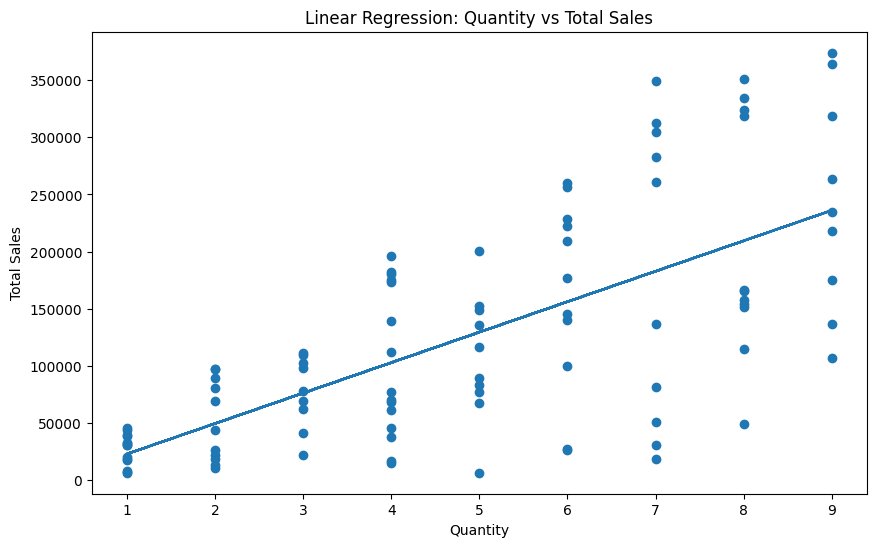

In [ ]:
# ------------------------------------------------
# Linear Regression
# Predict Total Sales using Quantity
# ------------------------------------------------


# Features and target
X = sales_df[['Quantity']]
y = sales_df['Total_Sales']

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Predictions
predictions = model.predict(X)

# Calculate R-squared
r_squared = r2_score(y, predictions)

# Print results
print("===== REGRESSION ANALYSIS =====")
print(f"Intercept: {model.intercept_}")
print(f"Slope (Coefficient): {model.coef_[0]}")
print(f"R-squared: {r_squared}")

# ------------------------------------------------
# Visualization
# ------------------------------------------------

plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(X, y)

# Regression line
plt.plot(X, predictions)

plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.title('Linear Regression: Quantity vs Total Sales')

plt.show()